# SAC - Mountain Car Continuous

In [1]:
%pip install gymnasium
%pip install "gymnasium[box2d]"
%pip install swig

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: C:\Users\jayde\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: C:\Users\jayde\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: C:\Users\jayde\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import gymnasium as gym
from train import train_sac
from agent import SACAgent
from buffer import PrioritizedReplayBuffer
from train import train_sac, OUNoise
import matplotlib.pyplot as plt
import numpy as np

In [3]:
env = gym.make("MountainCarContinuous-v0", render_mode=None)
agent = SACAgent(state_dim=env.observation_space.shape[0], action_dim=env.action_space.shape[0], hidden_dim=128, env=env, alpha_lr=3e-4, actor_lr=3e-4, critic_lr=3e-4)
replay_buffer = PrioritizedReplayBuffer(capacity=1_00_000, seed=0, alpha=0.6, eps=1e-5)
noise = OUNoise(action_dim=env.action_space.shape[0])

In [4]:
POTENTIAL_SCALE = 10.0

def mountain_car_potential(state):
    position, velocity = state[0], state[1]
    # kinematic_energy = 1/2 * mv^2
    # = 1/2 * 1 * v^2 = 0.5 * v^2
    kinematic_energy = 0.5 * velocity**2
    # Potential_energy = mgh
    # m = 1, g = 0.0025
    # PE directly proportional to h
    # h = sin(3x)
    potential_energy = np.sin(3*position)
    return POTENTIAL_SCALE + kinematic_energy + potential_energy

In [5]:
episode_rewards, critic1_loss, critic2_loss, actor_loss, alpha_loss, alpha, best_state_dict = train_sac(env=env, agent=agent, replay_buffer=replay_buffer, total_steps=100_000, batch_size=256, gamma=0.99, warmup_steps=10000, potential_fn=mountain_car_potential, exploration_noise=noise) 

  0%|          | 0/100000 [00:00<?, ?it/s]

  3%|▎         | 3359/100000 [00:00<00:02, 33421.90it/s]

Episode = 1, Reward = -45.4, Avg10 = -45.4, Best Reward=-45.4
Episode = 2, Reward = -45.1, Avg10 = -45.3, Best Reward=-45.1
Episode = 3, Reward = -47.1, Avg10 = -45.9, Best Reward=-45.1
Episode = 4, Reward = -49.1, Avg10 = -46.7, Best Reward=-45.1
Episode = 5, Reward = -44.4, Avg10 = -46.2, Best Reward=-44.4
Episode = 6, Reward = -47.7, Avg10 = -46.5, Best Reward=-44.4


 10%|▉         | 9845/100000 [00:00<00:03, 28690.26it/s]c:\Users\jayde\SAC\buffer.py:86: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  torch.FloatTensor(actions),


Episode = 7, Reward = -44.5, Avg10 = -46.2, Best Reward=-44.4
Episode = 8, Reward = -44.1, Avg10 = -45.9, Best Reward=-44.1
Episode = 9, Reward = -43.8, Avg10 = -45.7, Best Reward=-43.8
Episode = 10, Reward = -46.8, Avg10 = -45.8, Best Reward=-43.8


...

100%|█████████▉| 99864/100000 [2:01:08<00:08, 15.31it/s]

Episode = 764, Reward = 94.7, Avg10 = 94.8, Best Reward=96.3


100%|█████████▉| 99934/100000 [2:01:14<00:05, 11.95it/s]

Episode = 765, Reward = 95.1, Avg10 = 94.9, Best Reward=96.3


100%|██████████| 100000/100000 [2:01:19<00:00, 13.74it/s]


Text(0, 0.5, 'Rewards')

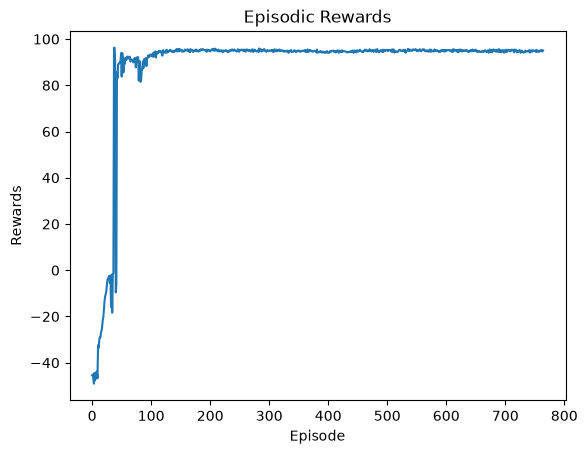

In [6]:
plt.plot(range(len(episode_rewards)), episode_rewards)
plt.title("Episodic Rewards")
plt.xlabel("Episode")
plt.ylabel("Rewards")

Text(0, 0.5, 'Critic 1 Loss')

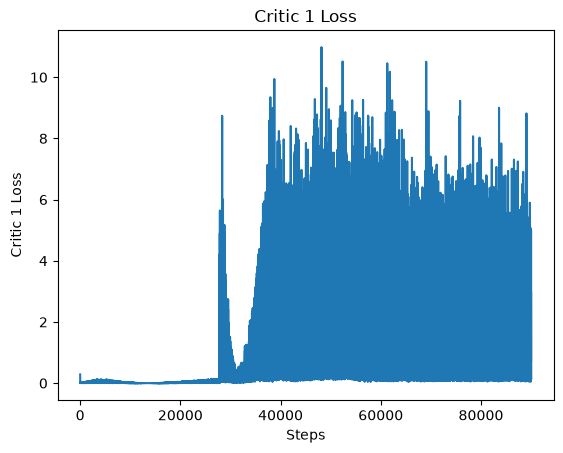

In [7]:
plt.plot(range(len(critic1_loss)), critic1_loss)
plt.title("Critic 1 Loss")
plt.xlabel("Steps")
plt.ylabel("Critic 1 Loss")

Text(0, 0.5, 'Critic 2 Loss')

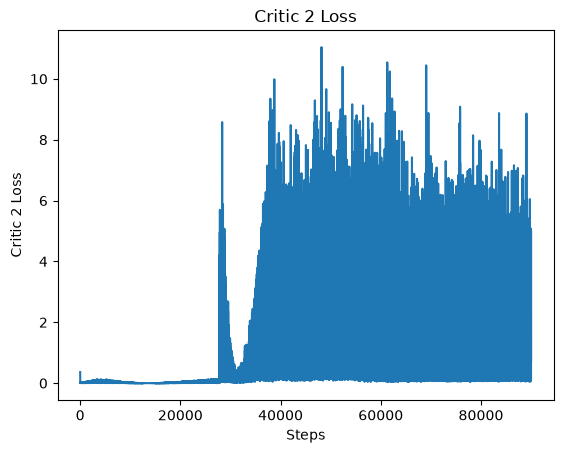

In [8]:
plt.plot(range(len(critic2_loss)), critic2_loss)
plt.title("Critic 2 Loss")
plt.xlabel("Steps")
plt.ylabel("Critic 2 Loss")

Text(0, 0.5, 'Actor Loss')

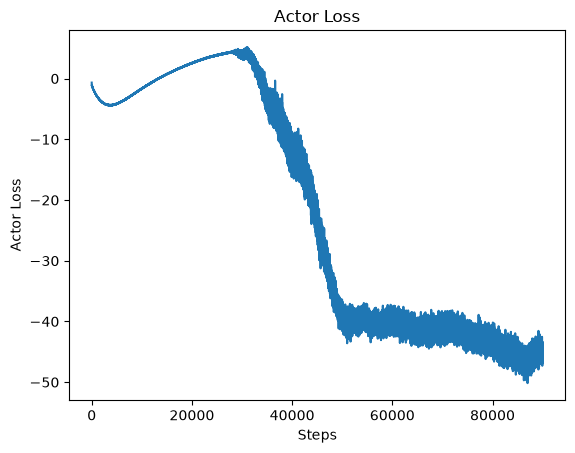

In [9]:
plt.plot(range(len(actor_loss)), actor_loss)
plt.title("Actor Loss")
plt.xlabel("Steps")
plt.ylabel("Actor Loss")

Text(0, 0.5, 'Alpha Loss')

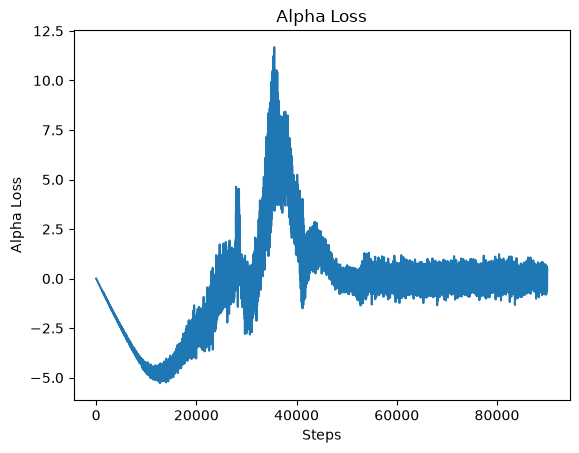

In [10]:
plt.plot(range(len(alpha_loss)), alpha_loss)
plt.title("Alpha Loss")
plt.xlabel("Steps")
plt.ylabel("Alpha Loss")

Text(0, 0.5, 'Alpha')

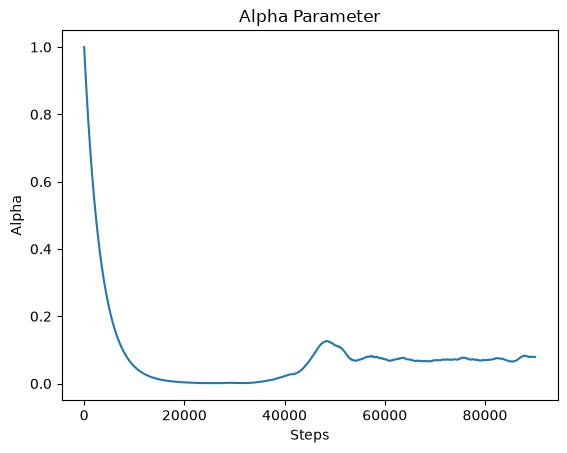

In [11]:
alpha_vals = [a.detach().cpu().item() for a in alpha]
plt.plot(range(len(alpha_vals)), alpha_vals)
plt.title("Alpha Parameter")
plt.xlabel("Steps")
plt.ylabel("Alpha")